# 03 — Diagnóstico por Imagem com CNN

**Tech Challenge — Fase 1 · Entrega extra** · Classificação de ultrassom mamário

Notebooks anteriores: [01 — Análise Exploratória](01_exploratory_analysis.ipynb) ·
[02 — Modelagem e Avaliação](02_modeling_evaluation.ipynb)

A discussão crítica do pipeline tabular apontou uma limitação central: **ele não parte de dados
crus**. As 30 features do Wisconsin já são o resultado de um especialista ter examinado a imagem e
medido os núcleos celulares. O modelo automatiza o *julgamento*, não a *extração* — e portanto não
reduz a carga de trabalho especializada.

Esta entrega ataca exatamente essa limitação: classificar a partir do pixel.

> Requer as dependências de visão computacional: `pip install -r requirements-vision.txt`

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

from src import config, plotting
from src.vision import dataset as vdata
from src.vision import evaluate as vevaluate
from src.vision import explain as vexplain
from src.vision import model as vmodel
from src.vision import train as vtrain

plotting.apply_style()
pd.set_option("display.width", 200)

# Sem isso, cada execução deste notebook produziria métricas diferentes.
vtrain.configure_determinism()

---
## 1. A base

**BUSI — Breast Ultrasound Images** (Al-Dhabyani et al., 2020), licença CC BY 4.0: 780 imagens de
ultrassom mamário em três classes. O enunciado do desafio autoriza explicitamente mamografias **ou
ultrassons**.

,classe,imagens,proporcao
0,benign,437,0.5603
1,malignant,210,0.2692
2,normal,133,0.1705


classes: ['benign', 'malignant', 'normal']
classe positiva: malignant


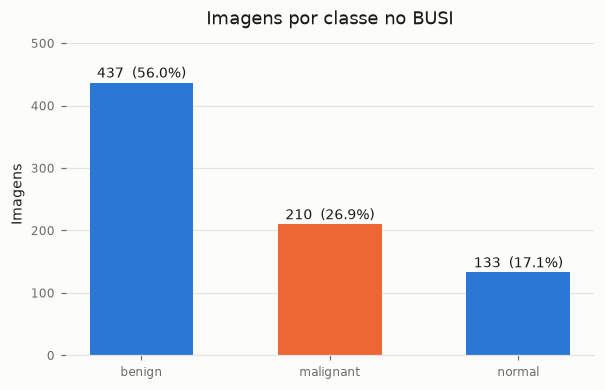

In [2]:
contagens = vdata.count_images()
display(contagens)

resumo = vdata.dataset_summary()
print(f"classes: {resumo['classes']}")
print(f"classe positiva: {resumo['classe_positiva']}")

vevaluate.plot_class_balance(contagens);

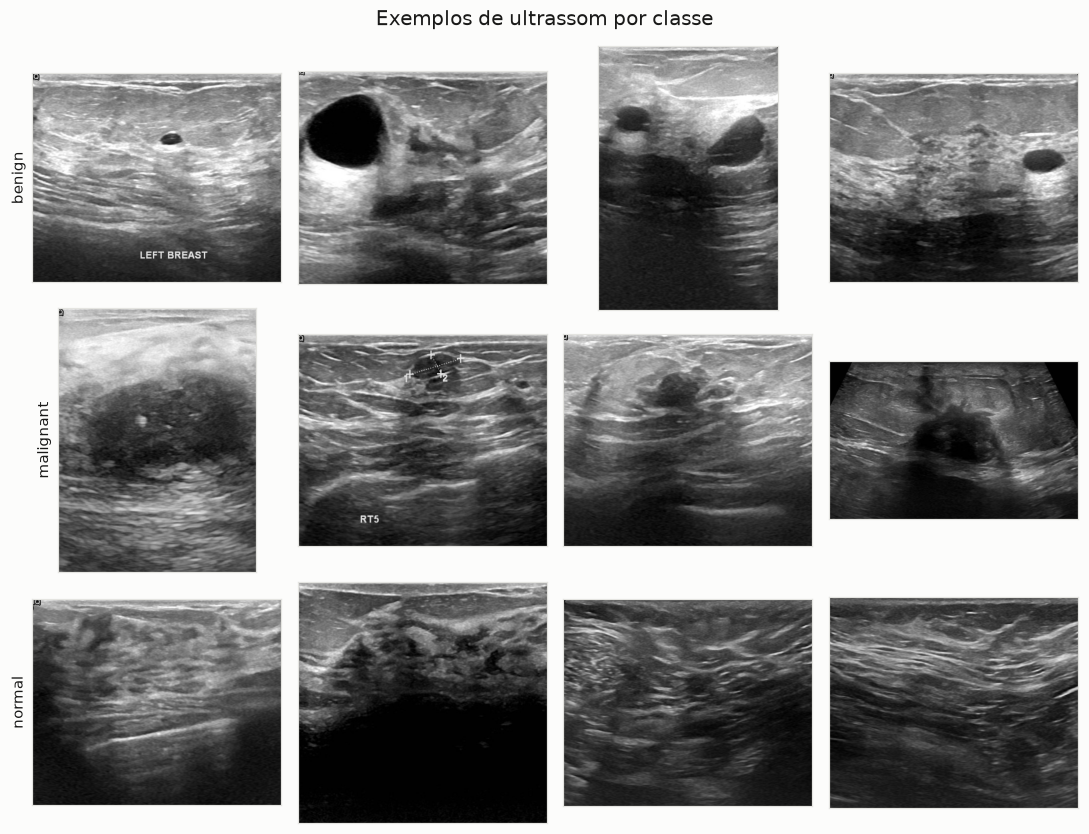

In [3]:
vevaluate.plot_samples(config.IMAGES_DIR, resumo["classes"]);

**Discussão.** A base é desbalanceada — 56% benignas, 27% malignas, 17% normais — e o desequilíbrio
é maior que no dataset tabular. O treino compensa com pesos de classe inversamente proporcionais à
frequência; sem isso, a rede aprenderia a favorecer a classe majoritária, que é o oposto do que
interessa quando a classe rara é a maligna.

Nas amostras, note o que **não** existe aqui: nenhuma medida, nenhuma tabela. A rede recebe o
mesmo que o médico vê na tela do aparelho.

---
## 2. Duplicatas: o problema que precede qualquer métrica

In [4]:
duplicatas = vdata.duplicate_summary()
for chave, valor in duplicatas.items():
    print(f"{chave:>36}: {valor}")

                             imagens: 780
                              grupos: 668
                grupos_com_repeticao: 95
                 imagens_redundantes: 112
   grupos_com_rotulos_contraditorios: 7


**Discussão — o achado que mudou o projeto.** O BUSI contém vários quadros do mesmo exame,
praticamente indistinguíveis. Uma auditoria por *hash* perceptual — que compara miniaturas em tons
de cinza e tolera diferenças de compressão — encontrou **112 imagens redundantes** entre as 780,
formando 95 grupos de repetição.

Distribuídas ao acaso, 62 desses pares caíam em partições diferentes: a rede era avaliada em
imagens que já tinha visto no treino. **É vazamento de dados** — o mesmo problema que o pipeline
tabular evita ao manter o `StandardScaler` dentro do `Pipeline`.

Pior ainda, **7 grupos têm rótulos contraditórios**: imagens praticamente idênticas catalogadas com
diagnósticos diferentes, incluindo um par byte a byte igual que aparece como `benign (433)` e como
`malignant (145)`. Sem acesso ao laudo original não há como decidir qual está correto, então os
casos foram mantidos e registrados — é um limite de qualidade da base, não do modelo.

---
## 3. Partição estratificada e agrupada

Duas exigências precisam valer ao mesmo tempo: a proporção das classes deve ser preservada
(estratificação) e nenhum grupo de quadros repetidos pode ser dividido entre conjuntos
(agrupamento). O `StratifiedGroupKFold` atende às duas.

In [5]:
particoes, class_names = vdata.stratified_split()
display(vdata.split_summary(particoes, class_names))

treino, validacao, teste, class_names = vdata.load_datasets()
pesos = vdata.class_weights(contagens, class_names)
print(f"pesos de classe: {pesos}")

,conjunto,imagens,benign,malignant,normal,proporcao_positiva
0,treino,556,311,150,95,0.2698
1,validacao,112,63,30,19,0.2679
2,teste,112,63,30,19,0.2679


pesos de classe: {0: 0.595, 1: 1.2381, 2: 1.9549}


**Discussão.** A proporção de casos malignos fica em 27,0% no treino e 26,8% na validação e no
teste, contra 26,9% na base completa. E, por construção, nenhum exame aparece em mais de um
conjunto.

Vale notar o contraste com o `image_dataset_from_directory` do Keras, que seria o caminho natural:
ele divide **aleatoriamente**, sem estratificar e sem agrupar. Em uma base pequena e desbalanceada,
isso deixaria ao acaso tanto a proporção de malignos no teste quanto a separação dos quadros
repetidos.

---
## 4. Arquiteturas comparadas

| Modelo | Ideia |
|---|---|
| **CNN do zero** | três blocos convolucionais treinados apenas com as 556 imagens disponíveis |
| **MobileNetV2 (transferência)** | base pré-treinada na ImageNet, congelada, com cabeça nova |
| **MobileNetV2 (ajuste fino)** | segunda etapa: as 60 camadas finais da base são liberadas, com taxa de aprendizado 10× menor |

In [6]:
modelos = vmodel.get_models(n_classes=len(class_names))
for nome, m in modelos.items():
    print(f"{nome}: {m.count_params():,} parâmetros".replace(",", "."))

CNN do zero: 110.147 parâmetros
MobileNetV2 (transferência): 2.261.827 parâmetros


**Aumento de dados apenas geométrico** — espelhamento, rotação leve, zoom e translação. Distorções
de cor seriam arriscadas: em imagem médica, a intensidade carrega informação diagnóstica.

O ajuste fino só faz sentido **depois** que a cabeça converge com a base congelada. Aplicado a pesos
aleatórios, os gradientes iniciais destruiriam as features pré-treinadas.

---
## 5. Treinamento

In [7]:
modelos, historicos, tabela_treino = vtrain.train_all(
    modelos, treino, validacao, class_weight=pesos, verbose=0
)
display(tabela_treino)

   treinando: CNN do zero


C:\workspace\ML-breast-cancer\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


   treinando: MobileNetV2 (transferência)


,modelo,parametros,epocas_treinadas,melhor_epoca,val_accuracy,val_loss,segundos
0,CNN do zero,110147,14,8,0.5625,0.9992,93.4
1,MobileNetV2 (transferência),2261827,26,20,0.8036,0.5275,136.0


C:\workspace\ML-breast-cancer\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


ajuste fino concluído em 78s


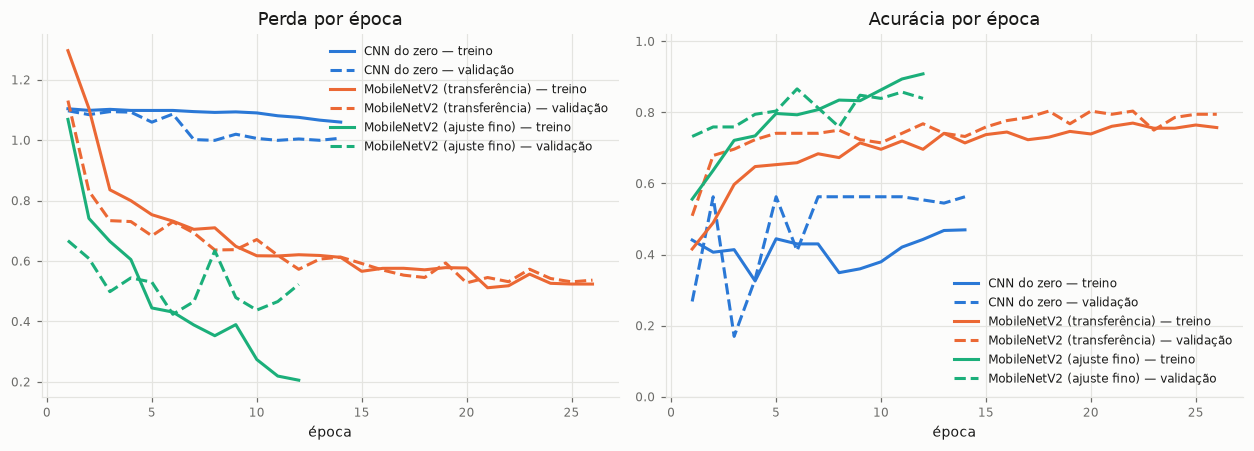

In [8]:
resultados_base = vevaluate.evaluate_all(modelos, teste, class_names)

modelo_transferencia = modelos["MobileNetV2 (transferência)"]
pesos_congelados = modelo_transferencia.get_weights()

historico_fino, segundos_fino = vtrain.fine_tune(
    modelo_transferencia, treino, validacao,
    class_weight=pesos, epochs=25, n_camadas=60, learning_rate=1e-4, verbose=0,
)
historicos["MobileNetV2 (ajuste fino)"] = historico_fino
metricas_fino = vevaluate.evaluate(modelo_transferencia, teste, class_names)

modelos["MobileNetV2 (ajuste fino)"] = modelo_transferencia
print(f"ajuste fino concluído em {segundos_fino:.0f}s")

vevaluate.plot_training_curves(historicos);

**Discussão.** A perda de validação da CNN do zero mal se move: com 556 imagens, não há dados
suficientes para aprender filtros visuais a partir do zero. A MobileNetV2 congelada converge rápido,
e o ajuste fino parte de um patamar já baixo — sua contagem de épocas recomeça do zero porque é uma
segunda etapa, não uma continuação do mesmo treino.

---
## 6. Avaliação no conjunto de teste

In [9]:
resultados = vevaluate.rank(
    pd.concat(
        [resultados_base, pd.DataFrame([{"modelo": "MobileNetV2 (ajuste fino)", **metricas_fino}])],
        ignore_index=True,
    )
)
display(resultados)

melhor = str(resultados.iloc[0]["modelo"])
print(f"melhor por recall da classe maligna: {melhor}")

,modelo,accuracy,precision,recall,f1,recall_maligno,precisao_maligno,malignos_no_teste,malignos_nao_detectados
0,MobileNetV2 (ajuste fino),0.8393,0.8725,0.8015,0.8214,0.9000,0.7714,30,3
1,MobileNetV2 (transferência),0.7589,0.7335,0.8041,0.7508,0.7667,0.6216,30,7
2,CNN do zero,0.5625,0.1875,0.3333,0.2400,0.0000,0.0000,30,30


melhor por recall da classe maligna: MobileNetV2 (ajuste fino)


**Discussão.** Três leituras, em ordem de importância.

**A CNN do zero não aprendeu a tarefa.** Com 56,3% de acurácia, ela não detectou **nenhum** dos 30
casos malignos do teste: aprendeu a responder "benigno", que é a resposta mais frequente. É a
demonstração mais direta do que o notebook 02 argumentou sobre a acurácia como métrica isolada — um
modelo pode acertar mais da metade das vezes e ter valor clínico zero.

**A transferência de aprendizado torna a tarefa viável** e **o ajuste fino a torna razoável.**
Liberar as 60 camadas finais elevou o recall maligno de 0,767 para 0,900, reduzindo de 7 para 3 os
casos não detectados — e ainda melhorou a precisão. As features da ImageNet servem de ponto de
partida, mas texturas de ultrassom não se parecem com fotografias naturais: adaptá-las é o que faz
diferença.

**A seleção continua sendo por recall da classe maligna**, como no pipeline tabular. Aqui os dois
critérios concordam, mas nem sempre foi assim durante o desenvolvimento — em uma partição anterior,
contaminada por duplicatas, o ajuste fino vencia em acurácia e F1 enquanto perdia em recall. A
métrica correta não é a que mostra o melhor número, é a que reflete o custo real do erro.

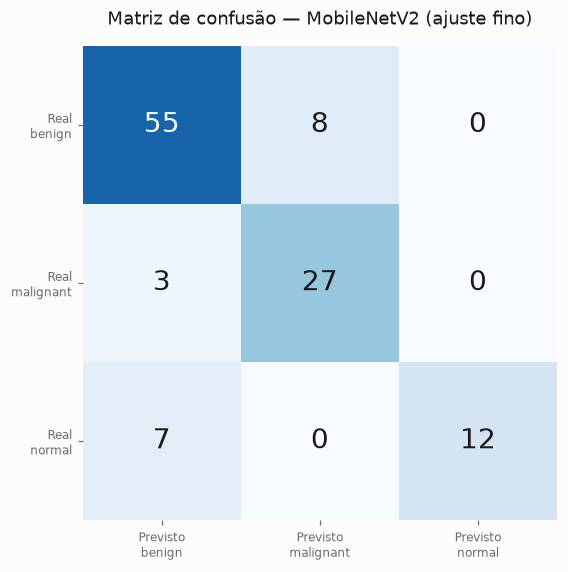

In [10]:
vevaluate.plot_confusion(modelos[melhor], teste, class_names, melhor);

**Discussão.** Dos 30 casos malignos, **27 foram corretamente identificados** e nenhum foi
confundido com tecido normal — os 3 erros foram classificados como benignos. Do lado dos falsos
alarmes, 8 benignos foram apontados como malignos, o que no fluxo clínico significa exames
adicionais: custo real, mas incomparavelmente menor que o de um diagnóstico perdido.

---
## 7. Explicabilidade: onde a rede olhou

O pipeline tabular responde "por que esta paciente?" com SHAP, decompondo a previsão em
contribuições por medida. Em imagem não existem medidas, existem pixels — e a pergunta equivalente
é **onde a rede olhou**.

figuras geradas: 25_gradcam_acertos.png e 26_gradcam_erros.png


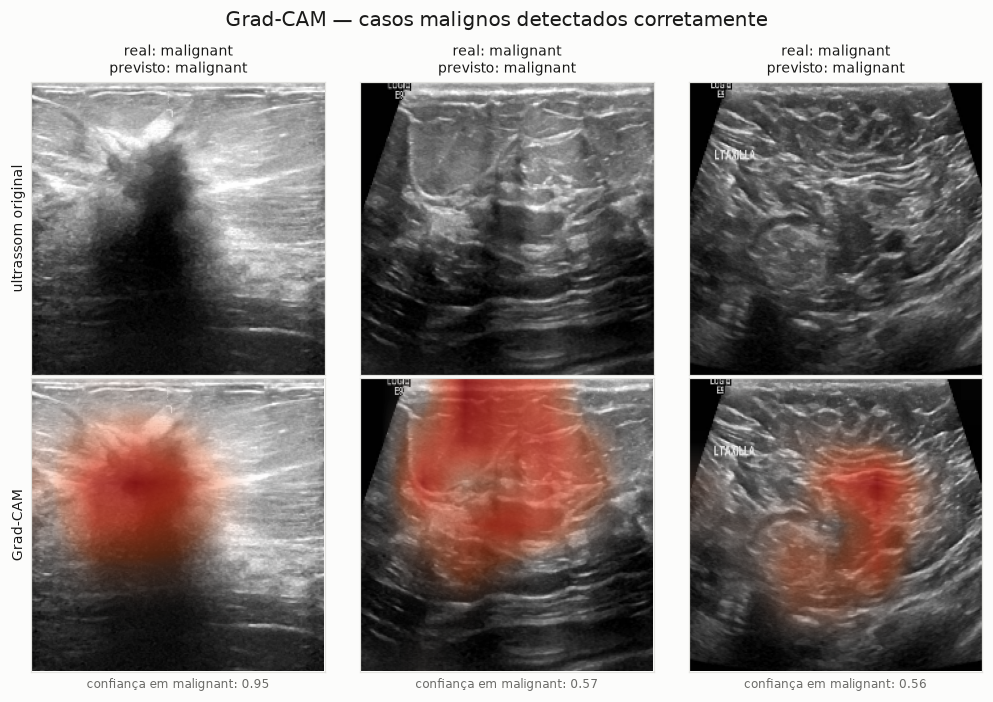

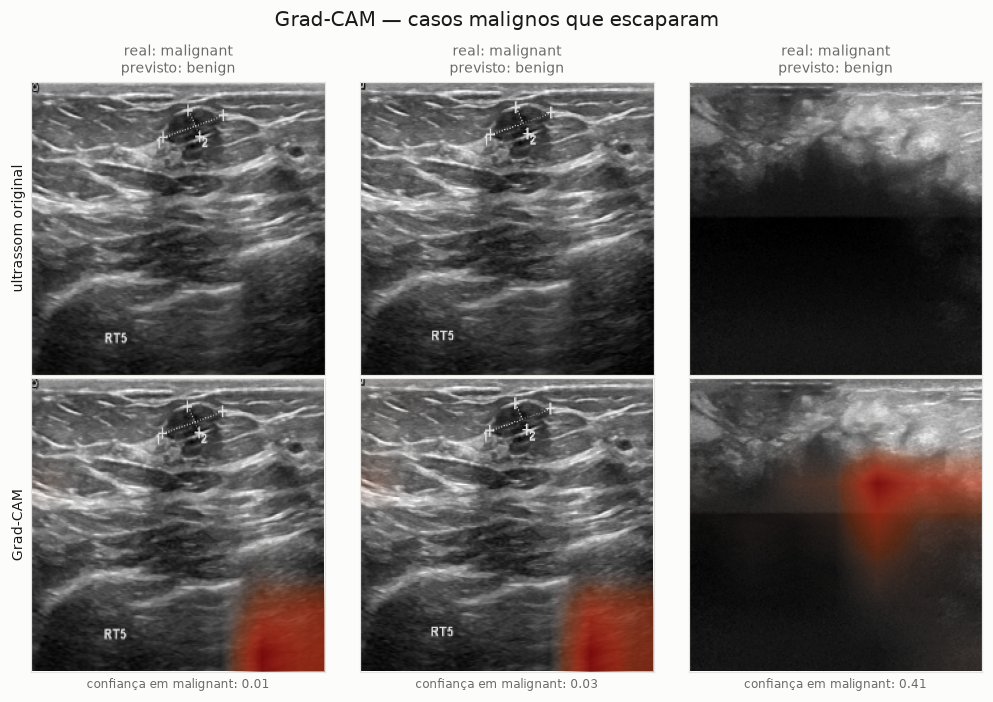

In [11]:
acertos, erros = vexplain.plot_gradcam_examples(modelos[melhor], teste, class_names)
print(f"figuras geradas: {acertos.name}" + (f" e {erros.name}" if erros else ""))

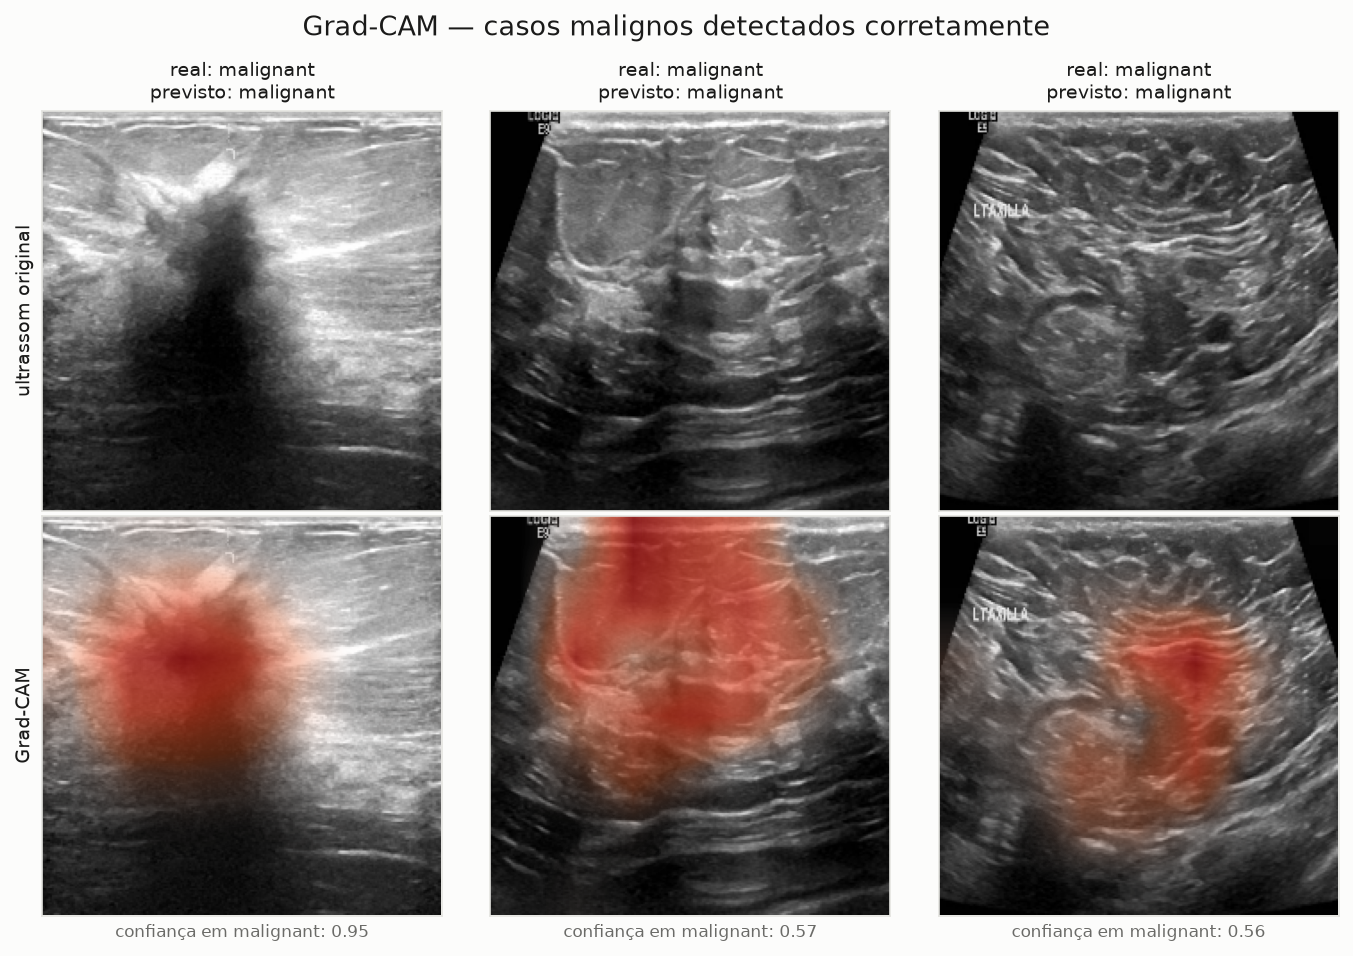

In [12]:
from IPython.display import Image, display as mostrar

mostrar(Image(filename=str(acertos)))

**Discussão.** Nos casos detectados corretamente, **o calor se concentra sobre a lesão**. No
primeiro, a massa hipoecoica central é exatamente a região que sustenta a previsão, com 0,95 de
confiança.

Isso não era garantido — e é justamente por isso que a explicabilidade existe. Um modelo pode
acertar olhando para o lugar errado, e nesse caso o acerto não se sustentaria em dados novos.

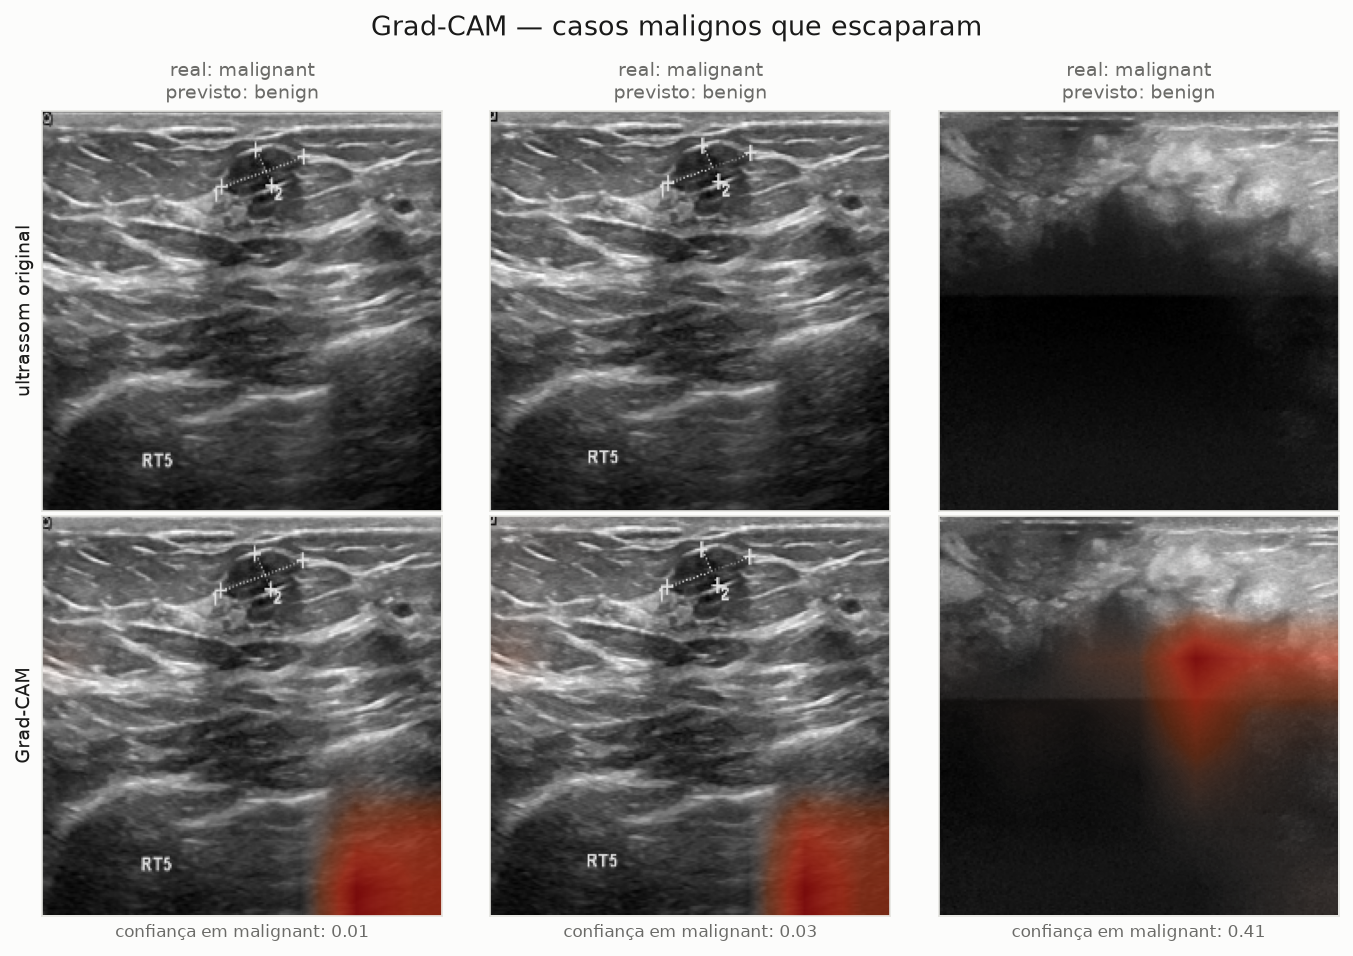

In [13]:
if erros:
    mostrar(Image(filename=str(erros)))

**Discussão — o caso mais instrutivo.** Nos casos que escaparam, o padrão se inverte: **a lesão
permanece fria e o calor migra para o canto inferior direito**, uma região de sombra acústica sem
relevância diagnóstica. O modelo não avaliou mal a lesão — ele não a considerou. A confiança na
classe maligna despenca para 0,01 e 0,03.

Duas observações adicionais. As imagens trazem **anotações gravadas em pixel** — marcadores de
medição em cruz, linha pontilhada, etiqueta de posição — feitas pelo profissional que já identificou
a lesão suspeita. Elas carregam informação do diagnóstico, e uma rede que aprendesse a reconhecê-las
teria desempenho alto e valor clínico nulo, porque em um exame novo não existem. Os mapas mostram
que, ao menos nestes casos, a atenção não se fixa nelas.

E as duas primeiras colunas são o **mesmo exame**, em quadros quase idênticos, ambos no conjunto de
teste — exatamente o que o agrupamento da seção 2 garante. Antes da correção, teriam sido
distribuídos entre treino e teste.

---
## Síntese da entrega extra

| Item | Resultado |
|---|---|
| Base | BUSI — 780 imagens, 668 exames distintos, 3 classes |
| Partição | estratificada e agrupada: 556 / 112 / 112 |
| Modelo escolhido | MobileNetV2 com ajuste fino das 60 camadas finais |
| Recall maligno | 0,900 (3 de 30 não detectados) |
| Acurácia | 0,839 · F1 macro 0,821 |
| Explicabilidade | Grad-CAM sobre a imagem |

**Comparação honesta com o pipeline tabular.** O modelo tabular alcança recall de 0,929, um pouco
acima — mas resolve um problema mais fácil, porque recebe medidas que um profissional já extraiu. O
modelo de imagem opera sobre o dado bruto, sem etapa manual anterior: está mais perto de um sistema
de triagem real e mais longe de estar pronto.

Com recall de 0,900, **1 em cada 10 tumores malignos ainda escaparia**. É adequado a uma
demonstração de viabilidade acadêmica e insuficiente para uso clínico. A conclusão do notebook 02
permanece intacta: o médico continua com a palavra final.